In [1]:
# Importing necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# For better visualization
sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# Loading the dataset

df = pd.read_csv("Telco-Customer-Churn.csv")

# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Shape of dataset

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 7043
Number of Columns: 21


In [4]:
# Column Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Statistical summary of dataset

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Checking missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Convert TotalCharges to numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("Missing values handled")

Missing values handled


C:\Users\HP\AppData\Local\Temp\ipykernel_7532\1648936441.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_7532\2699962940.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


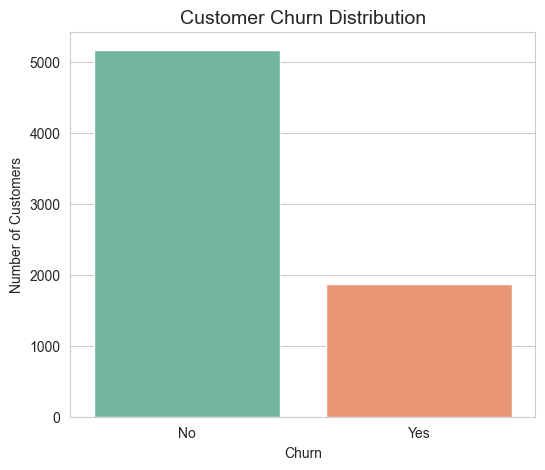

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(x='Churn', data=df, palette='Set2')

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

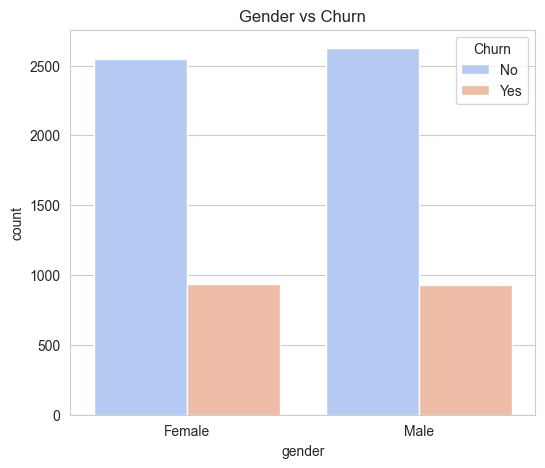

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(x='gender', hue='Churn', data=df, palette='coolwarm')

plt.title("Gender vs Churn")

plt.show()

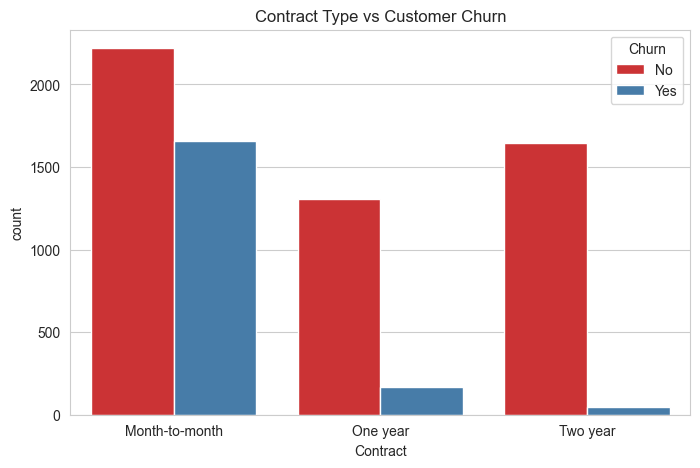

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')

plt.title("Contract Type vs Customer Churn")

plt.show()

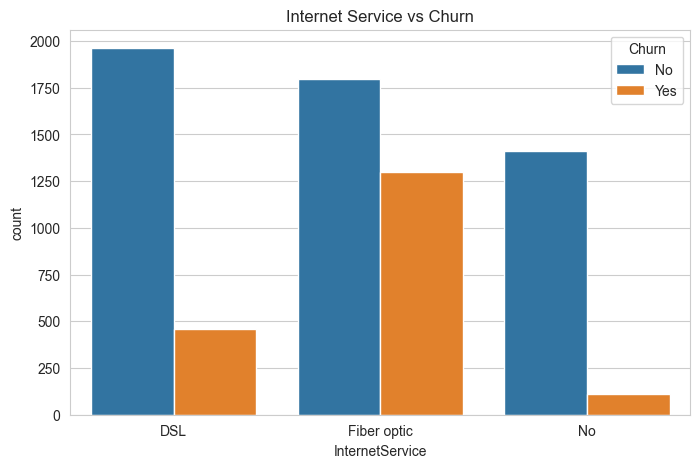

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Internet Service vs Churn")

plt.show()

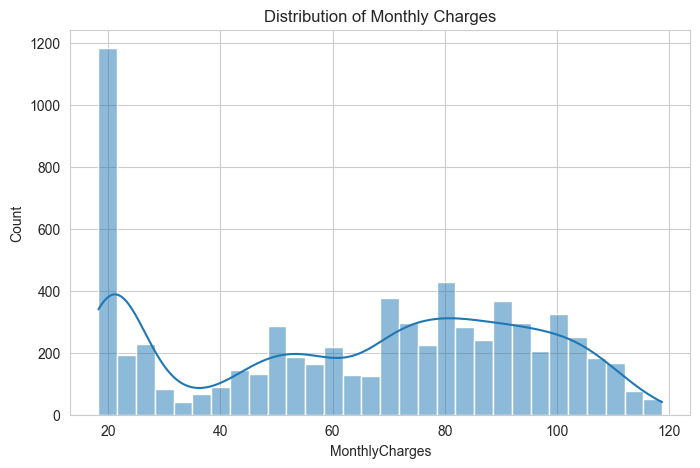

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")

plt.show()

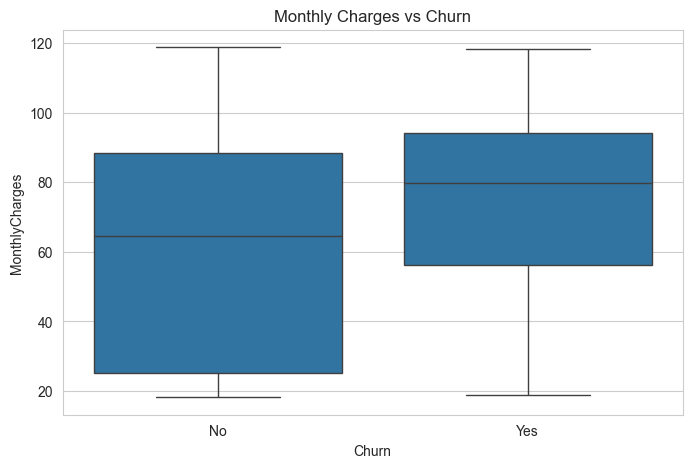

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

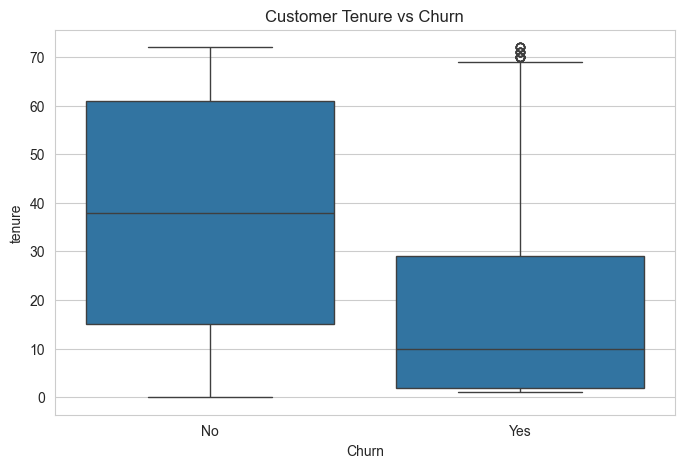

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Customer Tenure vs Churn")

plt.show()

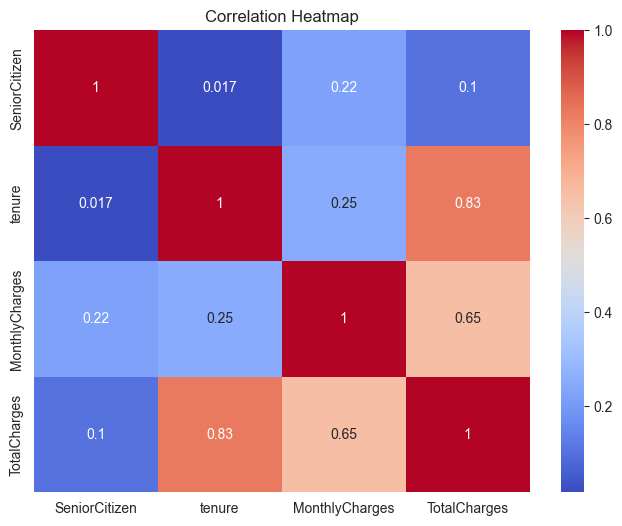

In [15]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [16]:
# Churn percentage

churn_rate = df['Churn'].value_counts(normalize=True) * 100

print("Churn Percentage:\n")
print(churn_rate)

Churn Percentage:

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [17]:
print("Key Insights from Customer Churn Analysis:\n")

print("1. Month-to-month contract customers show higher churn rates.")

print("2. Customers with shorter tenure are more likely to leave.")

print("3. Higher monthly charges slightly increase churn probability.")

print("4. Long-term contracts improve customer retention.")

print("5. Retention strategies should target new customers.")

Key Insights from Customer Churn Analysis:

1. Month-to-month contract customers show higher churn rates.
2. Customers with shorter tenure are more likely to leave.
3. Higher monthly charges slightly increase churn probability.
4. Long-term contracts improve customer retention.
5. Retention strategies should target new customers.


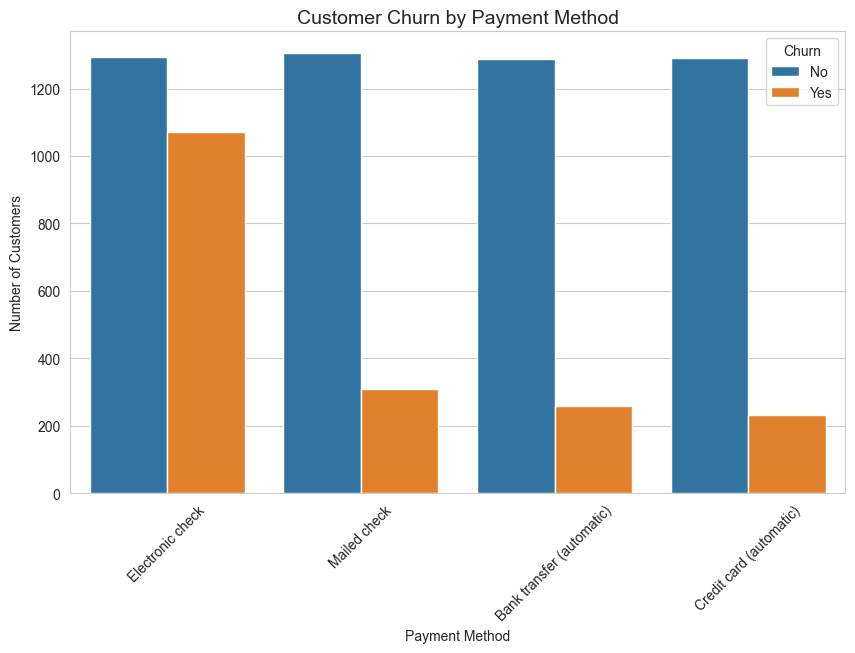

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.title("Customer Churn by Payment Method", fontsize=14)
plt.xticks(rotation=45)

plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.show()

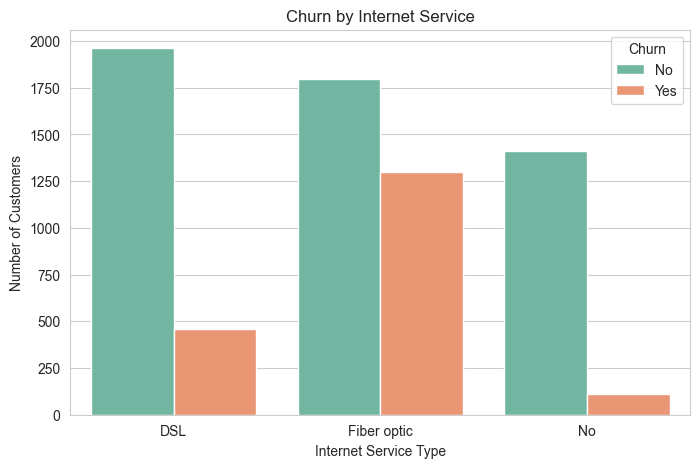

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')

plt.title("Churn by Internet Service")

plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")

plt.show()

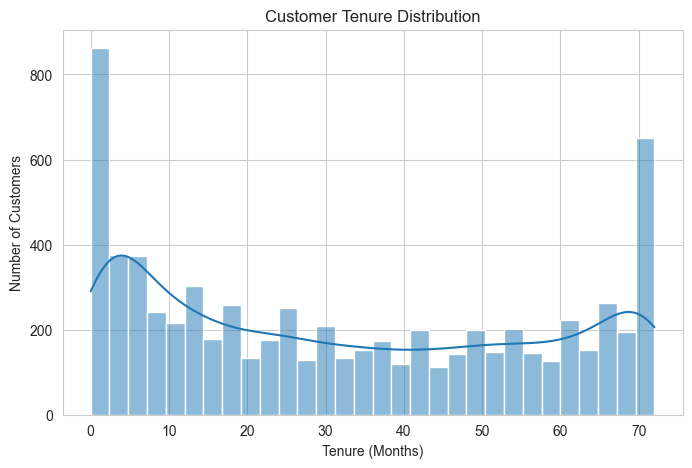

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df['tenure'], bins=30, kde=True)

plt.title("Customer Tenure Distribution")

plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

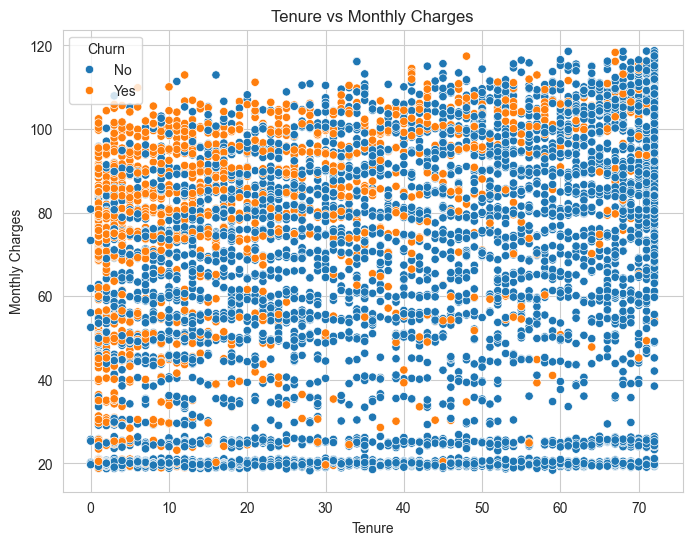

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df)

plt.title("Tenure vs Monthly Charges")

plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")

plt.show()

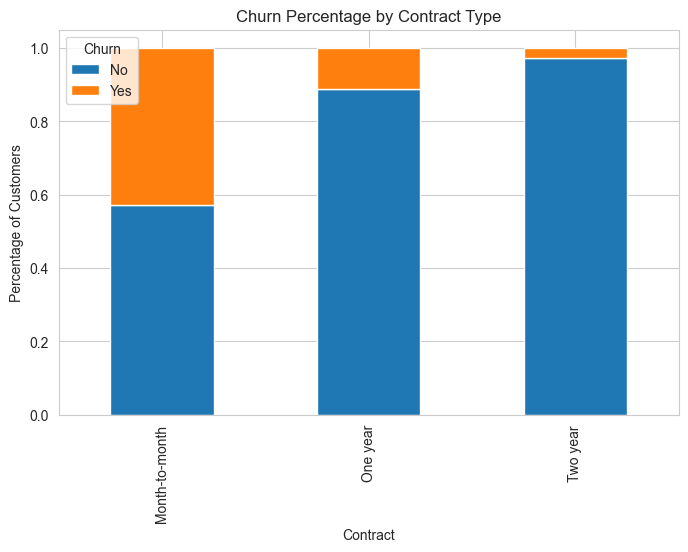

In [22]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index')

contract_churn.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Churn Percentage by Contract Type")

plt.ylabel("Percentage of Customers")

plt.legend(title="Churn")

plt.show()

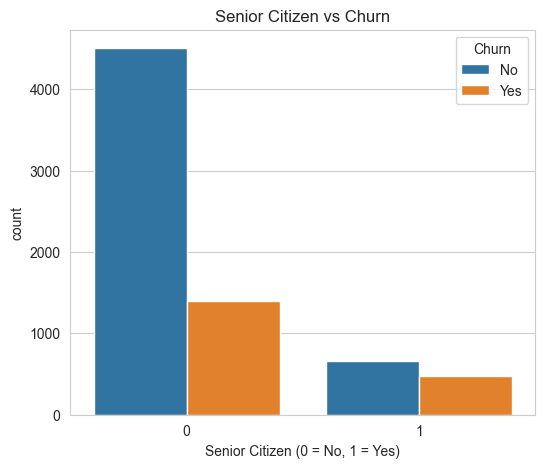

In [23]:
plt.figure(figsize=(6,5))

sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title("Senior Citizen vs Churn")

plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")

plt.show()

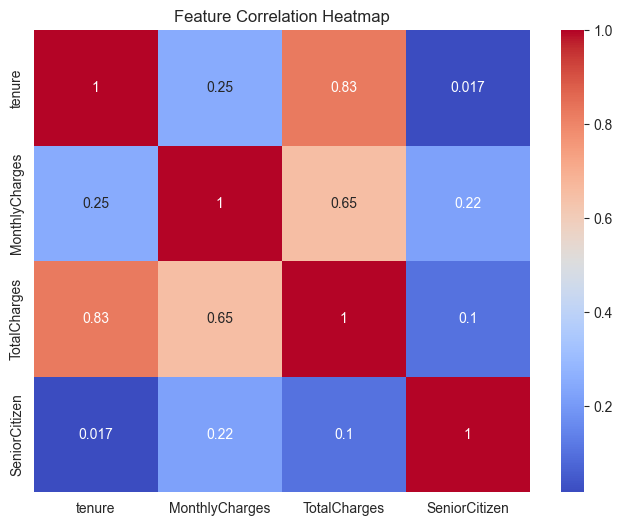

In [24]:
plt.figure(figsize=(8,6))

numeric_df = df[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']]

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

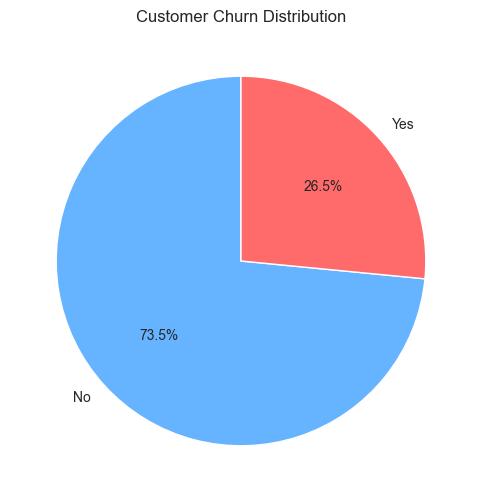

In [25]:
# Customer Churn Pie Chart

plt.figure(figsize=(6,6))

churn_counts = df['Churn'].value_counts()

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff','#ff6b6b']
)

plt.title("Customer Churn Distribution")

plt.show()

##### The pie chart illustrates the proportion of customers who stayed versus those who churned. A majority of customers remain with the company, while a smaller but significant percentage discontinue the service. Understanding this churn proportion helps businesses design better retention strategies.